**Baseline Model**

In [21]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

**Load the training and testing set CSV's**

In [15]:
output_dir = Path("outputs")

train_df = pd.read_csv(output_dir / "train_202605_split.csv", low_memory=False)
test_df = pd.read_csv(output_dir / "test_202605_split.csv", low_memory=False)

with open(output_dir / "preprocessing_metadata.json", "r") as f:
    metadata = json.load(f)

target_col = metadata["target_col"]

numeric_features = metadata["numeric_features"] + metadata["missing_flag_cols"]
categorical_features = metadata["categorical_features"] + metadata["boolean_features"]

# Keep only columns that actually exist
numeric_features = [col for col in numeric_features if col in train_df.columns]
categorical_features = [col for col in categorical_features if col in train_df.columns]

feature_cols = numeric_features + categorical_features

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Number of features before encoding:", len(feature_cols))

Train shape: (386862, 41)
Test shape: (12017, 41)
Number of features before encoding: 34


In [16]:
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (386862, 34)
y_train: (386862,)
X_test: (12017, 34)
y_test: (12017,)


**Build preprocessing pipeline**

Fill missing numeric values with the median

Use StandardScaler() for numeric stability

One Hot Encode categorical variables

In [17]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

**Train Linear Regression Model**

In [18]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['LivingArea','BedroomsTotal','BathroomsTotalInteger',..., 'NewConstructionYN','FireplaceYN','AttachedGarageYN']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be a

**Evaluate Linear Regression Model on Test Set**

In [19]:
y_pred = baseline_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Results")
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# Correlation between actual and predicted ClosePrice
correlation_r = np.corrcoef(y_test, y_pred)[0, 1]

print("Correlation r:", correlation_r)

Baseline Linear Regression Results
R²: 0.42443053624612515
MAE: 372465.59940598276
RMSE: 1273386.929769209
Correlation r: 0.651906243427112


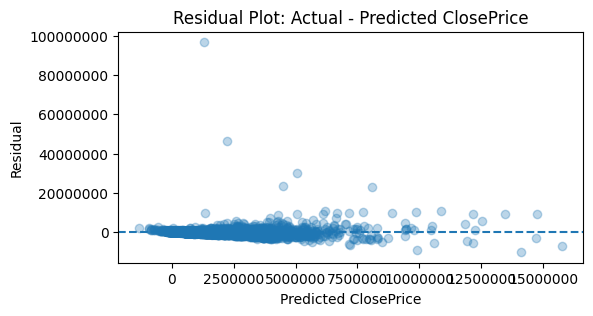

In [25]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(6, 3))

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.title("Residual Plot: Actual - Predicted ClosePrice")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")

plt.ticklabel_format(style="plain", axis="x")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

Many residuals are positive, meaning the model underpredicts

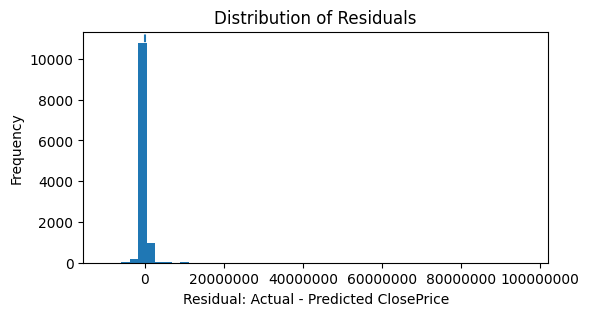

In [28]:
plt.figure(figsize=(6, 3))

plt.hist(residuals, bins=50)
plt.axvline(0, linestyle="--")

plt.title("Distribution of Residuals")
plt.xlabel("Residual: Actual - Predicted ClosePrice")
plt.ylabel("Frequency")

plt.ticklabel_format(style="plain", axis="x")

plt.show()

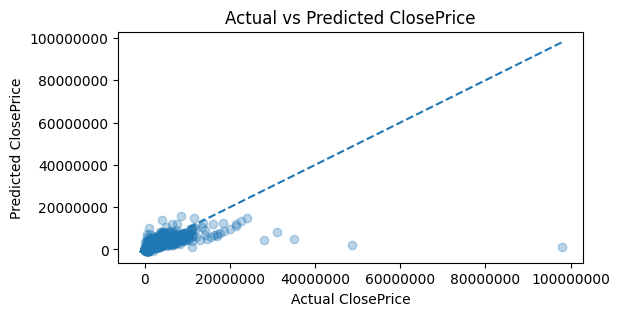

In [30]:
plt.figure(figsize=(6, 3))

plt.scatter(y_test, y_pred, alpha=0.3)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.title("Actual vs Predicted ClosePrice")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")

plt.ticklabel_format(style="plain", axis="x")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

**Save Baseline Model Metrics**

In [26]:
metrics_df = pd.DataFrame([{
    "model": "Linear Regression",
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "r2": r2,
    "correlation_r": correlation_r,
    "mae": mae,
    "rmse": rmse
}])

metrics_path = output_dir / "baseline_linear_regression_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

metrics_df

,model,train_rows,test_rows,r2,correlation_r,mae,rmse
0,Linear Regression,386862,12017,0.424431,0.651906,372465.599406,1.273387e+06
